In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

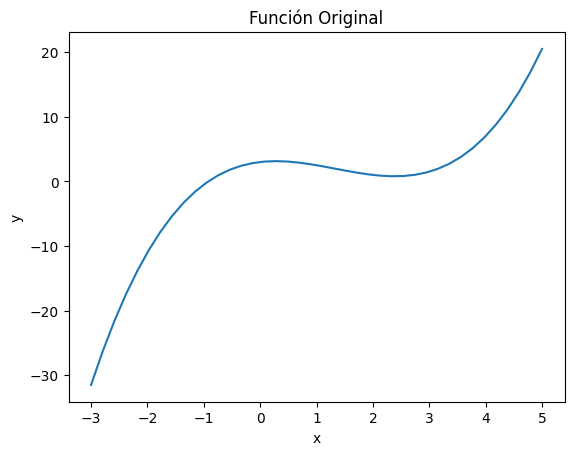

In [11]:
def true_function(x):
    return 0.5*x**3 - 2*x**2 + x + 3


# Generar datos
x = np.linspace(-3, 5, 40)
y = true_function(x)

plt.figure()
plt.plot(x, y)
plt.title("Función Original")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [12]:
X_train = torch.tensor(x.reshape(-1,1), dtype=torch.float32)
Y_train = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

print("Shape X:", X_train.shape)
print("Shape Y:", Y_train.shape)

Shape X: torch.Size([40, 1])
Shape Y: torch.Size([40, 1])


In [13]:
class SimpleNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1,16),
            nn.ReLU(),

            nn.Linear(16,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):
        return self.network(x)


model = SimpleNN()

In [14]:
learning_rate = 0.001

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print(model)
print("Learning Rate:", learning_rate)

SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Learning Rate: 0.001


In [ ]:
epochs = 10000

loss_history = []

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train)

    loss = criterion(y_pred, Y_train)

    optimizer.zero_grad() # Se necesita reiniciar los gradientes, para que no se acumulen. Esto no queire decir que se reinicie el modelo o que no se conduzca hacia el minimo sino que se reinicie el calculo de los gradientes.

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss {loss.item():.6f}")
        

Epoch 0 | Loss 101.110977
Epoch 100 | Loss 60.615807
Epoch 200 | Loss 25.960089
Epoch 300 | Loss 17.289085
Epoch 400 | Loss 10.883880
Epoch 500 | Loss 6.524562
Epoch 600 | Loss 3.990573
Epoch 700 | Loss 2.543912
Epoch 800 | Loss 1.586276
Epoch 900 | Loss 1.062980
Epoch 1000 | Loss 0.739154
Epoch 1100 | Loss 0.534420
Epoch 1200 | Loss 0.394288
Epoch 1300 | Loss 0.298006
Epoch 1400 | Loss 0.233962
Epoch 1500 | Loss 0.187335
Epoch 1600 | Loss 0.152405
Epoch 1700 | Loss 0.126214
Epoch 1800 | Loss 0.105576
Epoch 1900 | Loss 0.090149
Epoch 2000 | Loss 0.077045
Epoch 2100 | Loss 0.065659
Epoch 2200 | Loss 0.055441
Epoch 2300 | Loss 0.048188
Epoch 2400 | Loss 0.043657
Epoch 2500 | Loss 0.040303
Epoch 2600 | Loss 0.037747
Epoch 2700 | Loss 0.035760
Epoch 2800 | Loss 0.034187
Epoch 2900 | Loss 0.032880
Epoch 3000 | Loss 0.031678
Epoch 3100 | Loss 0.030564
Epoch 3200 | Loss 0.029521
Epoch 3300 | Loss 0.028538
Epoch 3400 | Loss 0.027604
Epoch 3500 | Loss 0.026703
Epoch 3600 | Loss 0.025826
Epoch 3

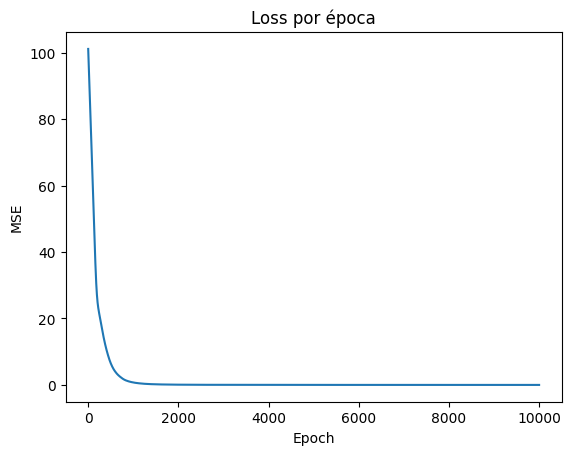

In [16]:
plt.figure()

plt.plot(loss_history)

plt.title("Loss por época")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.show()

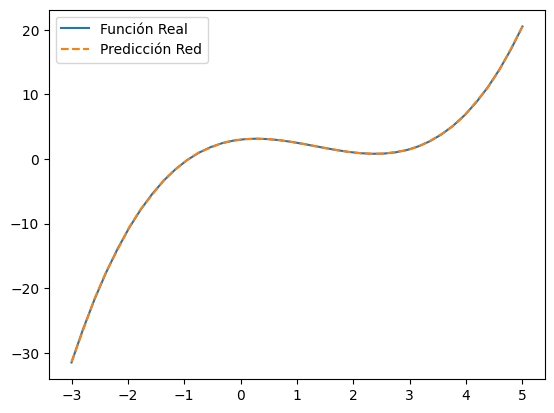

In [17]:
model.eval()

with torch.no_grad():

    y_pred = model(X_train).numpy()

plt.figure()

plt.plot(x, y, label="Función Real")
plt.plot(x, y_pred, "--", label="Predicción Red")

plt.legend()

plt.show()

In [18]:
new_x = 2.56

model.eval()

with torch.no_grad():

    prediction = model(torch.tensor([[new_x]],dtype=torch.float32)).item()

true_val = true_function(new_x)

print("Valor real:", true_val)
print("Predicción:", prediction)

Valor real: 0.8414080000000008
Predicción: 0.8355699777603149
